In [18]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

os.makedirs('../figures', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

In [19]:
with open('../results/results.json') as f:
    store = json.load(f)

print('Meta:', store['meta'])
print('Datasets available:', list(store['datasets'].keys()))

Meta: {'n_splits': 10, 'test_size': 0.2, 'seed': 0, 't_grid_points': 200, 'tabpfn_train_max': 1000, 'tabpfn_batch': 164}
Datasets available: ['whas500', 'gbsg', 'metabric']


In [20]:
# Flatten into a tidy DataFrame
records = []
for ds, methods in store['datasets'].items():
    for method, splits in methods.items():
        for s in splits:
            records.append({'dataset': ds, 'method': method,
                            'C-index': s['ci'], 'IBS': s['ibs']})

# Load FSA-BS (Gibbs last iteration) from results_gibbs.json
with open('../results/results_gibbs.json') as f:
    gibbs_store = json.load(f)
for ds, splits in gibbs_store['datasets'].items():
    for split_iters in splits:
        last = split_iters[-1]
        records.append({'dataset': ds, 'method': 'fsa_bs',
                        'C-index': last['CI'], 'IBS': last['IBS']})

df = pd.DataFrame(records)
datasets = list(store['datasets'].keys())
print(df.groupby(['dataset', 'method'])[['C-index', 'IBS']].mean().round(3))

                     C-index    IBS
dataset  method                    
gbsg     bin_fsa       0.673  0.190
         cox           0.661  0.190
         fsa           0.656  0.272
         fsa_bs        0.675  0.196
         lognormal     0.669  0.188
         pseudo_fsa    0.654  0.202
         rsf           0.677  0.185
         weibull       0.662  0.191
metabric bin_fsa       0.642  0.184
         cox           0.643  0.185
         fsa           0.619  0.229
         fsa_bs        0.654  0.191
         lognormal     0.646  0.187
         pseudo_fsa    0.637  0.206
         rsf           0.624  0.190
         weibull       0.643  0.185
whas500  bin_fsa       0.779  0.166
         cox           0.768  0.168
         fsa           0.699  0.311
         fsa_bs        0.765  0.178
         lognormal     0.767  0.171
         pseudo_fsa    0.740  0.182
         rsf           0.745  0.162
         weibull       0.769  0.169


In [21]:
import matplotlib.patches as mpatches

DATASET_LABELS = {
    'whas500':  'WHAS500',
    'gbsg':     'GBSG',
    'metabric': 'METABRIC',
    'support':  'SUPPORT',
    'flchain':  'FLCHAIN',
}

METHOD_ORDER = ['fsa', 'pseudo_fsa', 'fsa_bs', 'bin_fsa', 'cox', 'weibull', 'lognormal', 'rsf']

METHOD_LABELS = {
    'fsa':        'FSA (ours)',
    'pseudo_fsa': 'FSA-PO (ours)',
    'fsa_bs':     'FSA-BS (ours)',
    'bin_fsa':    'BinFSA (Kim et al.)',
    'cox':        'Cox PH',
    'weibull':    'Weibull AFT',
    'lognormal':  'LogNorm AFT',
    'rsf':        'RSF',
}

_C_FM       = '#9b8ec4'
_C_BIN      = '#6aab7e'
_C_BASELINE = '#6baed6'

METHOD_COLORS = {
    'fsa':        _C_FM,
    'pseudo_fsa': _C_FM,
    'fsa_bs':     _C_FM,
    'bin_fsa':    _C_BIN,
    'cox':        _C_BASELINE,
    'weibull':    _C_BASELINE,
    'lognormal':  _C_BASELINE,
    'rsf':        _C_BASELINE,
}

METHOD_HATCHES = {
    'fsa':        '',
    'pseudo_fsa': '//',
    'fsa_bs':     '||',
    'bin_fsa':    '',
    'cox':        '',
    'weibull':    '//',
    'lognormal':  'xx',
    'rsf':        '..',
}

present = [m for m in METHOD_ORDER if m in df['method'].unique()]

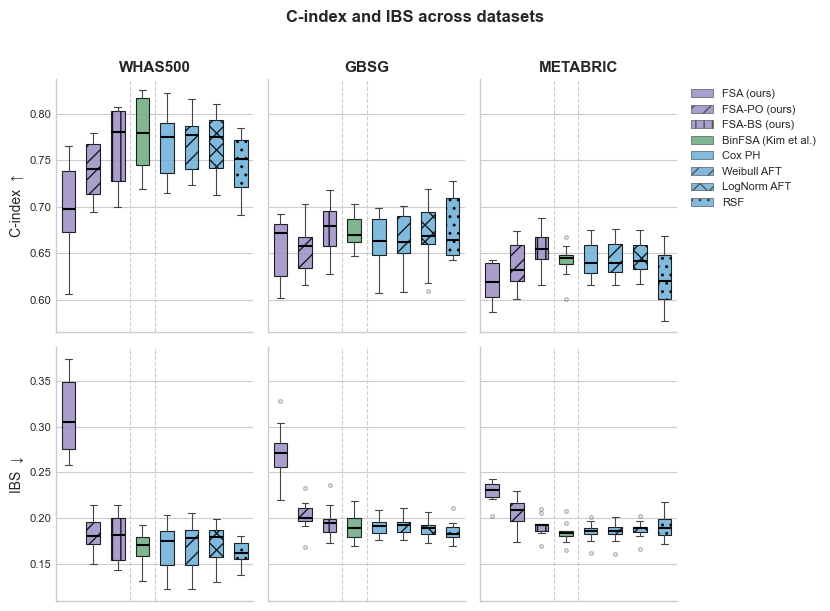

In [22]:
n_ds = len(datasets)
fig, axes = plt.subplots(2, n_ds, figsize=(2.8 * n_ds, 6), sharey='row')
if n_ds == 1:
    axes = axes.reshape(2, 1)

for col, ds in enumerate(datasets):
    sub = df[df['dataset'] == ds]
    for row, (metric, better) in enumerate([('C-index', '↑'), ('IBS', '↓')]):
        ax = axes[row, col]

        data = [sub[sub['method'] == m][metric].dropna().values for m in present]
        bp   = ax.boxplot(
            data, patch_artist=True, widths=0.55,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(linewidth=0.8, color='#444444'),
            capprops=dict(linewidth=0.8, color='#444444'),
            flierprops=dict(marker='o', markersize=2.5, alpha=0.4,
                            linestyle='none', markeredgecolor='#444444'),
        )
        for patch, m in zip(bp['boxes'], present):
            patch.set_facecolor(METHOD_COLORS[m])
            patch.set_hatch(METHOD_HATCHES[m])
            patch.set_linewidth(0.8)
            patch.set_alpha(0.85)

        if row == 0:
            ax.set_title(DATASET_LABELS.get(ds, ds), fontsize=11,
                         fontweight='bold', pad=5)
        ax.set_xticks([])
        ax.set_xlabel('')
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.tick_params(axis='y', labelsize=8)
        ax.set_ylabel(f'{metric}  {better}' if col == 0 else '', fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)

        for sep_after in ['fsa_bs', 'bin_fsa']:
            if sep_after in present:
                xpos = present.index(sep_after) + 1.5
                ax.axvline(xpos, color='#cccccc', linewidth=0.8, linestyle='--')

legend_handles = [
    mpatches.Patch(facecolor=METHOD_COLORS[m], hatch=METHOD_HATCHES[m],
                   edgecolor='#444444', linewidth=0.5, label=METHOD_LABELS[m],
                   alpha=0.85)
    for m in present
]
axes[0, -1].legend(handles=legend_handles, fontsize=8, frameon=False,
                   loc='upper left', bbox_to_anchor=(1.02, 1))

fig.suptitle('C-index and IBS across datasets', fontsize=12,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/results_boxplots.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../figures/results_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Summary table: mean ± std
rows = []
for ds in datasets:
    for method in present:
        sub = df[(df['dataset'] == ds) & (df['method'] == method)]
        if sub.empty:
            continue
        rows.append({
            'Dataset': ds, 'Method': METHOD_LABELS[method],
            'C-index': f"{sub['C-index'].mean():.3f} ± {sub['C-index'].std():.3f}",
            'IBS':     f"{sub['IBS'].mean():.3f} ± {sub['IBS'].std():.3f}",
        })

table = pd.DataFrame(rows).set_index(['Dataset', 'Method'])
display(table)
print('\nLaTeX:')
print(table.to_latex())

C-index            IBS
Dataset  Method                                           
whas500  FSA (ours)           0.699 ± 0.048  0.311 ± 0.043
         FSA-PO (ours)        0.740 ± 0.031  0.182 ± 0.020
         FSA-BS (ours)        0.765 ± 0.043  0.178 ± 0.027
         BinFSA (Kim et al.)  0.779 ± 0.040  0.166 ± 0.020
         Cox PH               0.768 ± 0.037  0.168 ± 0.026
         Weibull AFT          0.769 ± 0.032  0.169 ± 0.026
         LogNorm AFT          0.767 ± 0.032  0.171 ± 0.022
         RSF                  0.745 ± 0.032  0.162 ± 0.014
gbsg     FSA (ours)           0.656 ± 0.033  0.272 ± 0.030
         FSA-PO (ours)        0.654 ± 0.025  0.202 ± 0.017
         FSA-BS (ours)        0.675 ± 0.028  0.196 ± 0.018
         BinFSA (Kim et al.)  0.673 ± 0.018  0.190 ± 0.015
         Cox PH               0.661 ± 0.031  0.190 ± 0.009
         Weibull AFT          0.662 ± 0.032  0.191 ± 0.010
         LogNorm AFT          0.669 ± 0.035  0.188 ± 0.009
         RSF                  0.677 ± 0.034  0.185 ± 0.012
metabric FSA (ours)           0.619 ± 0.021  0.229 ± 0.012
         FSA-PO (ours)        0.637 ± 0.025  0.206 ± 0.016
         FSA-BS (ours)        0.654 ± 0.021  0.191 ± 0.011
         BinFSA (Kim et al.)  0.642 ± 0.018  0.184 ± 0.011
         Cox PH               0.643 ± 0.021  0.185 ± 0.011
         Weibull AFT          0.643 ± 0.021  0.185 ± 0.011
         LogNorm AFT          0.646 ± 0.018  0.187 ± 0.010
         RSF                  0.624 ± 0.030  0.190 ± 0.014


LaTeX:
\begin{tabular}{llll}
\toprule
 &  & C-index & IBS \\
Dataset & Method &  &  \\
\midrule
\multirow[t]{8}{*}{whas500} & FSA (ours) & 0.699 ± 0.048 & 0.311 ± 0.043 \\
 & FSA-PO (ours) & 0.740 ± 0.031 & 0.182 ± 0.020 \\
 & FSA-BS (ours) & 0.765 ± 0.043 & 0.178 ± 0.027 \\
 & BinFSA (Kim et al.) & 0.779 ± 0.040 & 0.166 ± 0.020 \\
 & Cox PH & 0.768 ± 0.037 & 0.168 ± 0.026 \\
 & Weibull AFT & 0.769 ± 0.032 & 0.169 ± 0.026 \\
 & LogNorm AFT & 0.767 ± 0.032 & 0.171 ± 0.022 \\
 & RSF & 0.745 ± 0.032 & 0.162 ± 0.014 \\
\cline{1-4}
\multirow[t]{8}{*}{gbsg} & FSA (ours) & 0.656 ± 0.033 & 0.272 ± 0.030 \\
 & FSA-PO (ours) & 0.654 ± 0.025 & 0.202 ± 0.017 \\
 & FSA-BS (ours) & 0.675 ± 0.028 & 0.196 ± 0.018 \\
 & BinFSA (Kim et al.) & 0.673 ± 0.018 & 0.190 ± 0.015 \\
 & Cox PH & 0.661 ± 0.031 & 0.190 ± 0.009 \\
 & Weibull AFT & 0.662 ± 0.032 & 0.191 ± 0.010 \\
 & LogNorm AFT & 0.669 ± 0.035 & 0.188 ± 0.009 \\
 & RSF & 0.677 ± 0.034 & 0.185 ± 0.012 \\
\cline{1-4}
\multirow[t]{8}{*}{metabric} & F

In [24]:
# --- FSA-BS: load Gibbs results ---
with open('../results/results_gibbs.json') as f:
    gibbs = json.load(f)

# Build tidy DataFrame: one row per (dataset, split, iteration)
gibbs_records = []
for ds, splits in gibbs['datasets'].items():
    for split_idx, iters in enumerate(splits):
        for row in iters:
            gibbs_records.append({
                'dataset': ds,
                'split':   split_idx,
                'Iter':    row['Iter'],
                'CI':      row['CI'],
                'IBS':     row['IBS'],
                'Sigma':   row['Sigma'],
            })

gdf = pd.DataFrame(gibbs_records)
print('Datasets:', gdf['dataset'].unique())
print('Iterations:', sorted(gdf['Iter'].unique()))
print(gdf.groupby(['dataset', 'Iter'])[['CI', 'IBS', 'Sigma']].mean().round(3))

Datasets: ['whas500' 'gbsg' 'metabric']
Iterations: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
                  CI    IBS  Sigma
dataset  Iter                     
gbsg     1     0.509  0.243  3.341
         2     0.596  0.216  2.107
         3     0.631  0.203  1.648
         4     0.648  0.198  1.321
         5     0.660  0.191  1.143
         6     0.668  0.189  1.006
         7     0.673  0.189  0.933
         8     0.674  0.191  0.884
         9     0.675  0.194  0.854
         10    0.675  0.196  0.851
metabric 1     0.574  0.251  2.273
         2     0.626  0.207  1.431
         3     0.647  0.193  1.195
         4     0.650  0.191  1.072
         5     0.652  0.191  1.021
         6     0.651  0.192  0.994
         7     0.652  0.192  0.985
         8     0.649  0.193  0.976
         9     0.651  0.193  0.970
         10    0.654  0.191  0.975
whas500  1     0.619  0.208  5.307
         2 

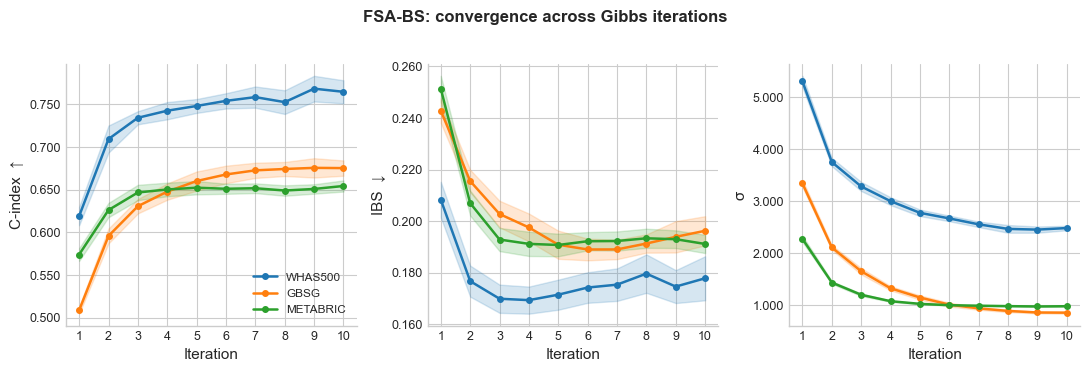

In [25]:
# --- Gibbs convergence: CI, IBS, Sigma vs iteration ---
gibbs_datasets = list(gibbs['datasets'].keys())
palette_g = sns.color_palette("tab10", n_colors=len(gibbs_datasets))

metrics_to_plot = [('CI', 'C-index  ↑'), ('IBS', 'IBS  ↓'), ('Sigma', 'σ')]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))

for ax, (col, ylabel) in zip(axes, metrics_to_plot):
    for ds, color in zip(gibbs_datasets, palette_g):
        sub   = gdf[gdf['dataset'] == ds]
        iters = sorted(sub['Iter'].unique())
        means = np.array([sub[sub['Iter'] == it][col].mean() for it in iters])
        ses   = np.array([sub[sub['Iter'] == it][col].std() /
                          np.sqrt(sub[sub['Iter'] == it][col].count()) for it in iters])

        ax.plot(iters, means, marker='o', markersize=4, linewidth=1.8,
                color=color, label=DATASET_LABELS.get(ds, ds))
        ax.fill_between(iters, means - ses, means + ses, alpha=0.18, color=color)

    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(iters)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    ax.tick_params(labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(fontsize=8.5, frameon=False)
fig.suptitle('FSA-BS: convergence across Gibbs iterations', fontsize=12,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/gibbs_convergence.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../figures/gibbs_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

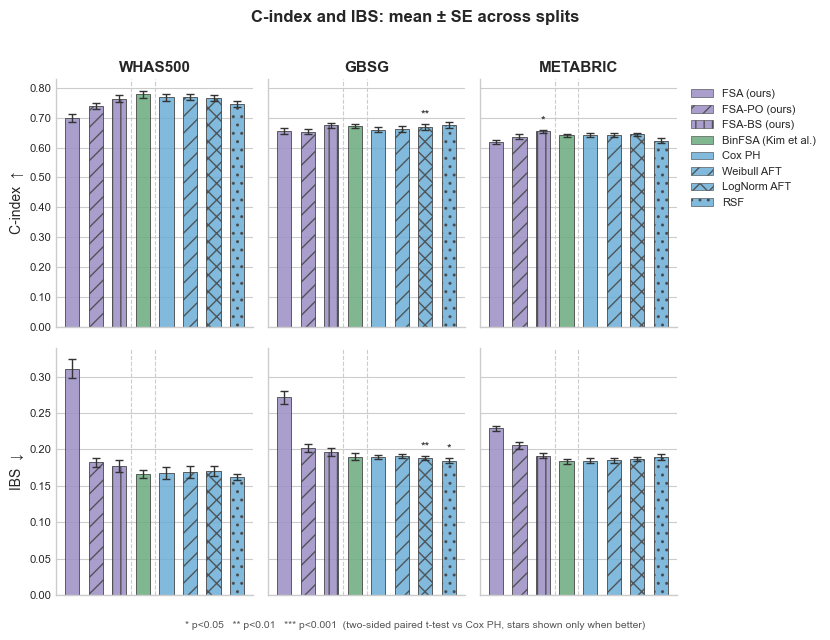

In [26]:
from scipy import stats

def _stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

# Split-level arrays for paired tests
split_data = {}
for ds, methods in store['datasets'].items():
    split_data[ds] = {}
    for method, splits in methods.items():
        split_data[ds][method] = {
            'C-index': np.array([s['ci'] for s in splits]),
            'IBS':     np.array([s['ibs'] for s in splits]),
        }
for ds, splits in gibbs_store['datasets'].items():
    split_data.setdefault(ds, {})
    split_data[ds]['fsa_bs'] = {
        'C-index': np.array([spl[-1]['CI'] for spl in splits]),
        'IBS':     np.array([spl[-1]['IBS'] for spl in splits]),
    }

REF = 'cox'
n_ds = len(datasets)
fig, axes = plt.subplots(2, n_ds, figsize=(2.8 * n_ds, 6), sharey='row')
if n_ds == 1:
    axes = axes.reshape(2, 1)

for col, ds in enumerate(datasets):
    for row, (metric, better, sign) in enumerate([('C-index', '↑', 1), ('IBS', '↓', -1)]):
        ax = axes[row, col]
        ref_vals = split_data[ds][REF][metric]

        xs    = np.arange(len(present))
        means = np.array([split_data[ds][m][metric].mean() for m in present])
        ses   = np.array([split_data[ds][m][metric].std() / np.sqrt(len(split_data[ds][m][metric]))
                          for m in present])

        ax.bar(xs, means, yerr=ses, width=0.6,
               color=[METHOD_COLORS[m] for m in present],
               hatch=[METHOD_HATCHES[m] for m in present],
               edgecolor='#444444', linewidth=0.7, alpha=0.85,
               error_kw=dict(elinewidth=1.0, capsize=3, capthick=1.0, ecolor='#333333'))

        # Stars: paired t-test vs Cox PH, one-sided by direction
        for xi, m in enumerate(present):
            if m == REF:
                continue
            m_vals = split_data[ds][m][metric]
            _, p   = stats.ttest_rel(m_vals, ref_vals)
            # Only annotate if the difference is in the "better" direction
            if sign * (m_vals - ref_vals).mean() > 0:
                s = _stars(p)
                if s:
                    ax.annotate(s, xy=(xi, means[xi] + ses[xi]),
                                xytext=(0, 3), textcoords='offset points',
                                ha='center', va='bottom', fontsize=8.5, color='#222222')

        if row == 0:
            ax.set_title(DATASET_LABELS.get(ds, ds), fontsize=11, fontweight='bold', pad=5)
        ax.set_xticks([])
        ax.set_xlabel('')
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.tick_params(axis='y', labelsize=8)
        ax.set_ylabel(f'{metric}  {better}' if col == 0 else '', fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)

        for sep_after in ['fsa_bs', 'bin_fsa']:
            if sep_after in present:
                ax.axvline(present.index(sep_after) + 0.5,
                           color='#cccccc', linewidth=0.8, linestyle='--')

legend_handles = [
    mpatches.Patch(facecolor=METHOD_COLORS[m], hatch=METHOD_HATCHES[m],
                   edgecolor='#444444', linewidth=0.5, label=METHOD_LABELS[m], alpha=0.85)
    for m in present
]
axes[0, -1].legend(handles=legend_handles, fontsize=8, frameon=False,
                   loc='upper left', bbox_to_anchor=(1.02, 1))
fig.text(0.5, -0.02,
         '* p<0.05   ** p<0.01   *** p<0.001  (two-sided paired t-test vs Cox PH, stars shown only when better)',
         ha='center', fontsize=7.5, color='#555555')
fig.suptitle('C-index and IBS: mean ± SE across splits', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/results_bars.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../figures/results_bars.png', dpi=300, bbox_inches='tight')
plt.show()